In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('../datasets/fish_data.csv')

In [3]:
df.head(10)

,species,length,weight,w_l_ratio
0,Anabas testudineus,10.66,3.45,0.32
1,Anabas testudineus,6.91,3.27,0.47
2,Anabas testudineus,8.38,3.46,0.41
3,Anabas testudineus,7.57,3.36,0.44
4,Anabas testudineus,10.83,3.38,0.31
5,Anabas testudineus,9.35,3.28,0.35
6,Anabas testudineus,9.42,3.33,0.35
7,Anabas testudineus,7.92,3.13,0.39
8,Anabas testudineus,6.98,3.16,0.45
9,Anabas testudineus,8.42,3.26,0.39


In [4]:
df.shape

(4080, 4)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4080 entries, 0 to 4079
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   species    4080 non-null   str    
 1   length     4080 non-null   float64
 2   weight     4080 non-null   float64
 3   w_l_ratio  4080 non-null   float64
dtypes: float64(3), str(1)
memory usage: 127.6 KB


In [6]:
df.describe()

,length,weight,w_l_ratio
count,4080.000000,4080.000000,4080.000000
mean,17.353544,3.739875,0.252782
std,7.114684,1.040365,0.123046
min,6.360000,2.050000,0.080000
25%,11.327500,3.070000,0.170000
50%,17.350000,3.310000,0.190000
75%,22.585000,4.100000,0.340000
max,33.860000,6.290000,0.640000


In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.duplicated().sum()

np.int64(109)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(3971, 4)

In [56]:
X = df.drop('species', axis=1)
Y["Species"] = df.species

In [12]:
X

,length,weight,w_l_ratio
0,10.66,3.45,0.32
1,6.91,3.27,0.47
2,8.38,3.46,0.41
3,7.57,3.36,0.44
4,10.83,3.38,0.31
...,...,...,...
4074,30.61,6.08,0.20
4075,30.56,6.12,0.20
4076,29.66,6.11,0.21
4077,32.81,6.25,0.19


In [13]:
Y.value_counts()

species
Setipinna taty            476
Anabas testudineus        462
Otolithoides biauritus    456
Pethia conchonius         454
Polynemus paradiseus      454
Sillaginopsis panijus     429
Otolithoides pama         428
Coilia dussumieri         409
Puntius lateristriga      403
Name: count, dtype: int64

In [14]:
z_scores = pd.DataFrame(stats.zscore(X))
z_scores

,0,1,2
0,-0.945026,-0.270714,0.553657
1,-1.475775,-0.445401,1.776943
2,-1.267721,-0.261009,1.287629
3,-1.382363,-0.358058,1.532286
4,-0.920966,-0.338648,0.472105
...,...,...,...
3966,1.878556,2.281659,-0.424972
3967,1.871479,2.320478,-0.424972
3968,1.744100,2.310774,-0.343420
3969,2.189929,2.446641,-0.506525


In [15]:
z_scores.describe().round(3)

,0,1,2
count,3971.000,3971.000,3971.000
mean,-0.000,-0.000,-0.000
std,1.000,1.000,1.000
min,-1.554,-1.629,-1.404
25%,-0.846,-0.639,-0.670
50%,0.003,-0.407,-0.507
75%,0.736,0.350,0.717
max,2.339,2.485,3.163


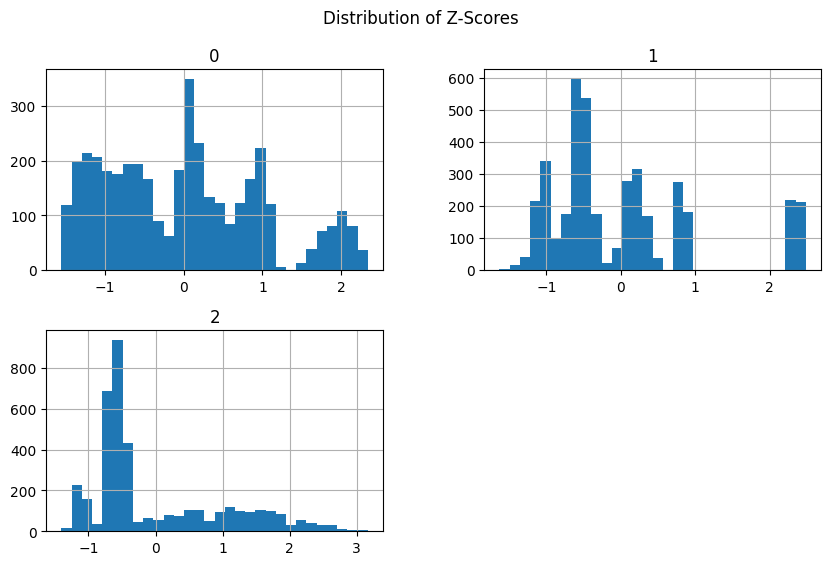

In [16]:
z_scores.hist(figsize=(10, 6), bins=30)
plt.suptitle("Distribution of Z-Scores")
plt.show()

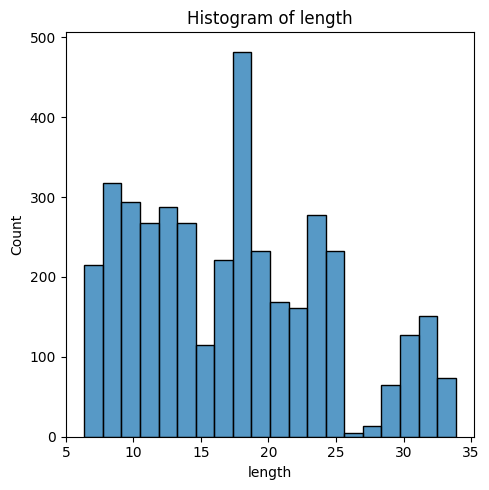

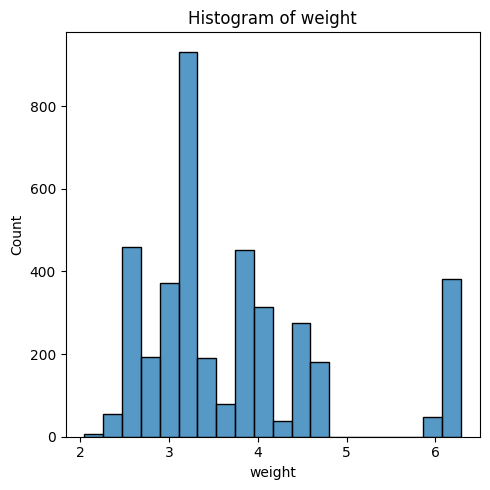

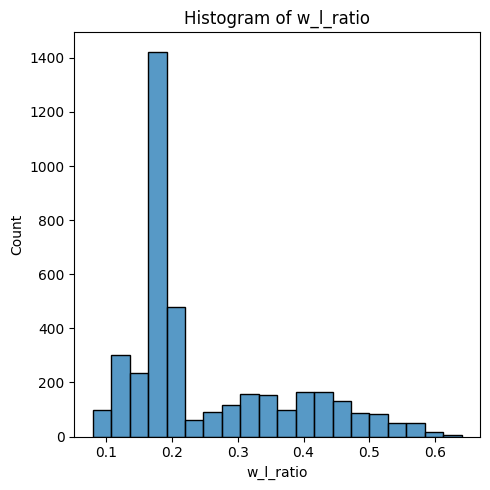

In [17]:
for column in X:
    plt.figure(figsize=(5, 5))
    sns.histplot(data=X, x=column, bins=20)
    plt.title(f'Histogram of {column}')
    
    plt.tight_layout()
    plt.show()

<Axes: xlabel='length', ylabel='weight'>

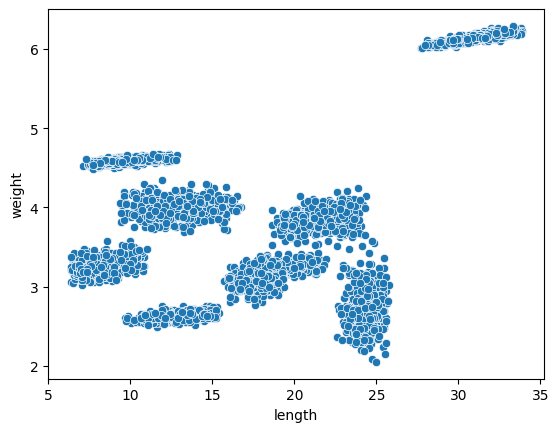

In [18]:
sns.scatterplot(
    x=df.length,
    y=df.weight
)

<Axes: xlabel='length', ylabel='w_l_ratio'>

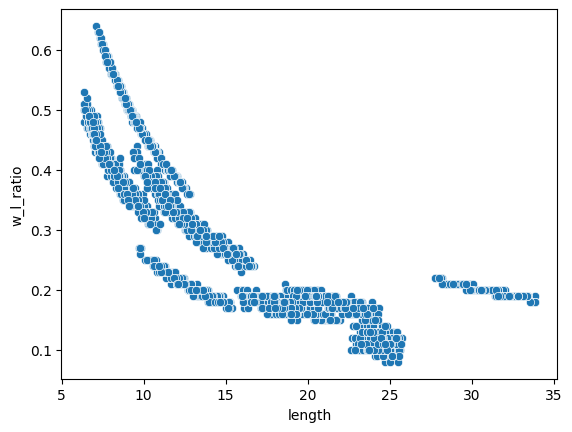

In [19]:
sns.scatterplot(
    x=df.length,
    y=df.w_l_ratio
)

<Axes: xlabel='weight', ylabel='w_l_ratio'>

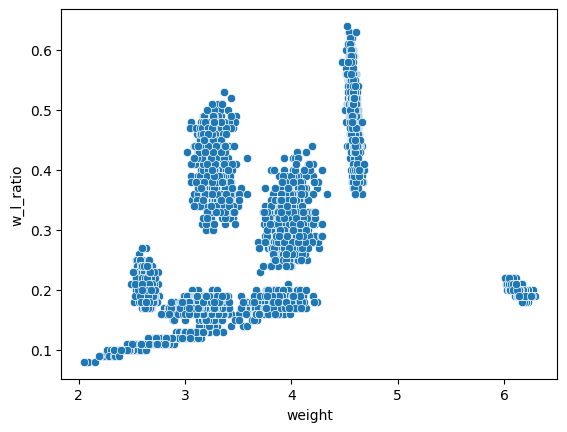

In [20]:
sns.scatterplot(
    x=df.weight,
    y=df.w_l_ratio
)

In [21]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(3971, 2)


In [23]:
X_pca.round(3)

array([[-0.277, -0.   ],
       [-0.54 ,  0.098],
       [-0.427,  0.082],
       ...,
       [ 0.561,  0.454],
       [ 0.681,  0.467],
       [ 0.639,  0.444]], shape=(3971, 2))

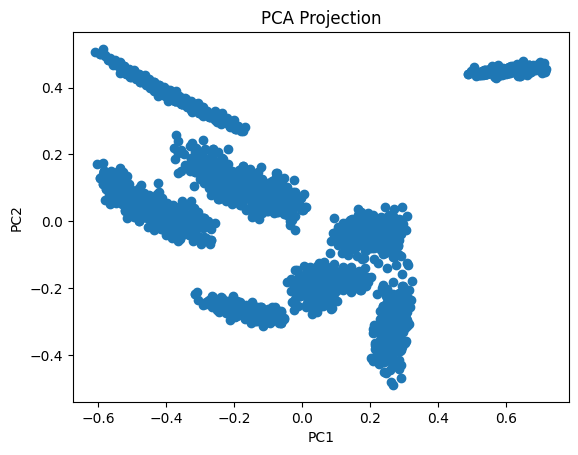

In [24]:
plt.scatter(X_pca[:,0], X_pca[:,1])

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection')
plt.show()

In [25]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

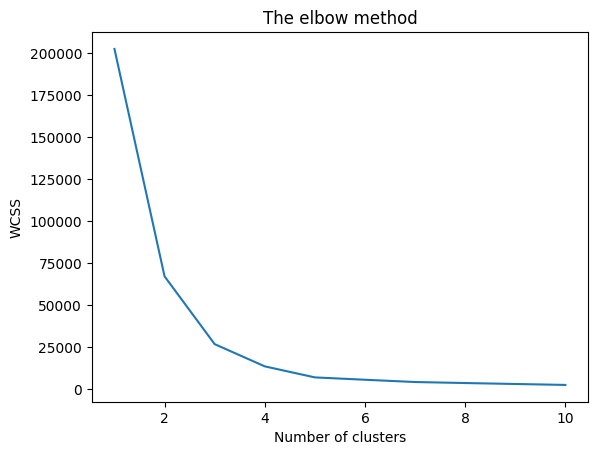

In [26]:
plt.plot(range(1, 11), wcss)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [27]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

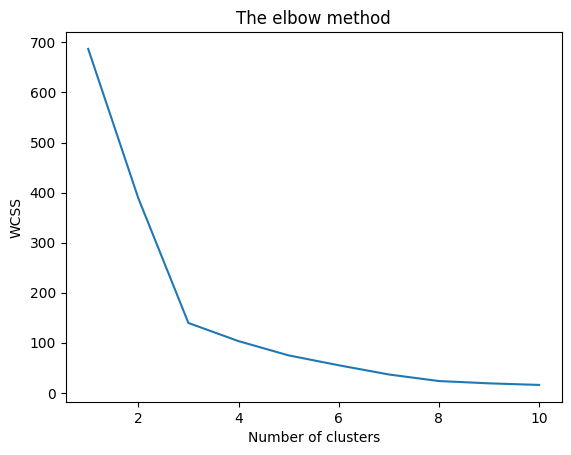

In [28]:
plt.plot(range(1, 11), wcss)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [29]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

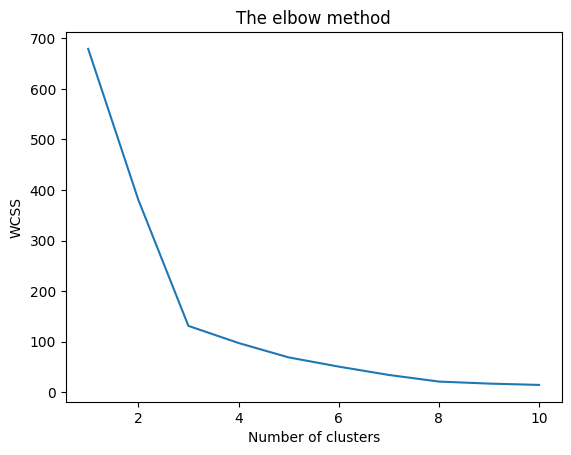

In [30]:
plt.plot(range(1, 11), wcss)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [31]:
for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_pca)

    score = silhouette_score(X_scaled, labels)
    print(k, score)

2 0.584108775400153
3 0.6160690059516349
4 0.5499080810217866
5 0.4659436167177436
6 0.5245870265268592
7 0.5933596110072901
8 0.5822613703996521
9 0.5733755484529081
10 0.6460102957209536


In [32]:
X_transformed = scaler.inverse_transform(X_scaled)

pd.DataFrame(X_transformed, columns=X.columns).head()

,length,weight,w_l_ratio
0,10.66,3.45,0.32
1,6.91,3.27,0.47
2,8.38,3.46,0.41
3,7.57,3.36,0.44
4,10.83,3.38,0.31


In [33]:
kmeans = KMeans(n_clusters=3, max_iter=100)
y_kmeans = kmeans.fit_predict(X_scaled)


In [34]:
np.unique(y_kmeans)

array([0, 1, 2], dtype=int32)

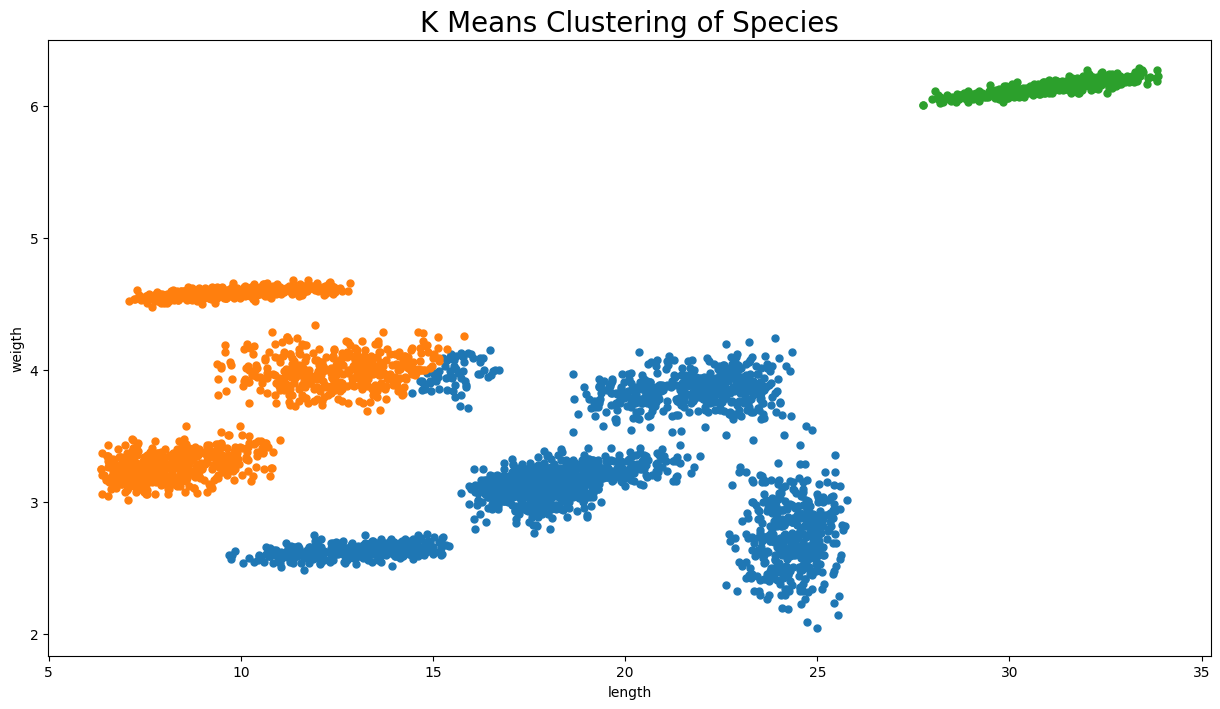

In [35]:
plt.figure(figsize= (15,8))

for i in range(len(np.unique(y_kmeans))):
    plt.scatter(X_transformed[y_kmeans == i, 0], X_transformed[y_kmeans == i, 1], s=25)

plt.title('K Means Clustering of Species', fontsize=20)
plt.xlabel('length')
plt.ylabel('weigth')

plt.show()

In [36]:
dbscan = DBSCAN(
    eps = 0.03,
    min_samples=10
)

y_dbscan = dbscan.fit_predict(X_scaled)

In [37]:
np.unique(y_dbscan)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7])

In [38]:
y_dbscan

array([0, 0, 0, ..., 7, 7, 7], shape=(3971,))

In [39]:
X['y_dbscan'] = y_dbscan

In [40]:
d = X[X['y_dbscan']==-1]

Text(0.5, 0, 'length')

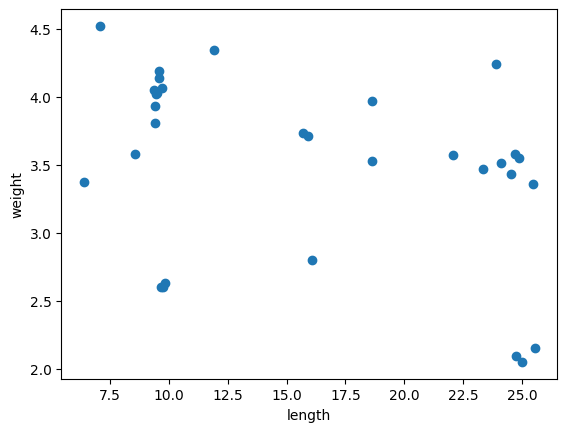

In [41]:
plt.scatter(
    x=d.length,
    y=d.weight,
)

plt.ylabel('weight')
plt.xlabel('length')

In [60]:
species = np.unique(Y.Species)

In [68]:
plot_df = X
plot_df['Species'] = Y.Species

In [69]:
plot_df.head()

,length,weight,w_l_ratio,Species
0,10.66,3.45,0.32,Anabas testudineus
1,6.91,3.27,0.47,Anabas testudineus
2,8.38,3.46,0.41,Anabas testudineus
3,7.57,3.36,0.44,Anabas testudineus
4,10.83,3.38,0.31,Anabas testudineus


AttributeError: PathCollection.set() got an unexpected keyword argument 'hue'

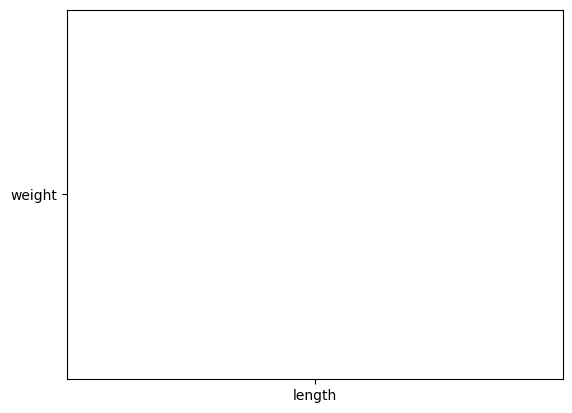

In [72]:
plt.scatter(
    x='length',
    y='weight',
    hue = 'Species'
)

plt.ylabel('weight')
plt.xlabel('length')

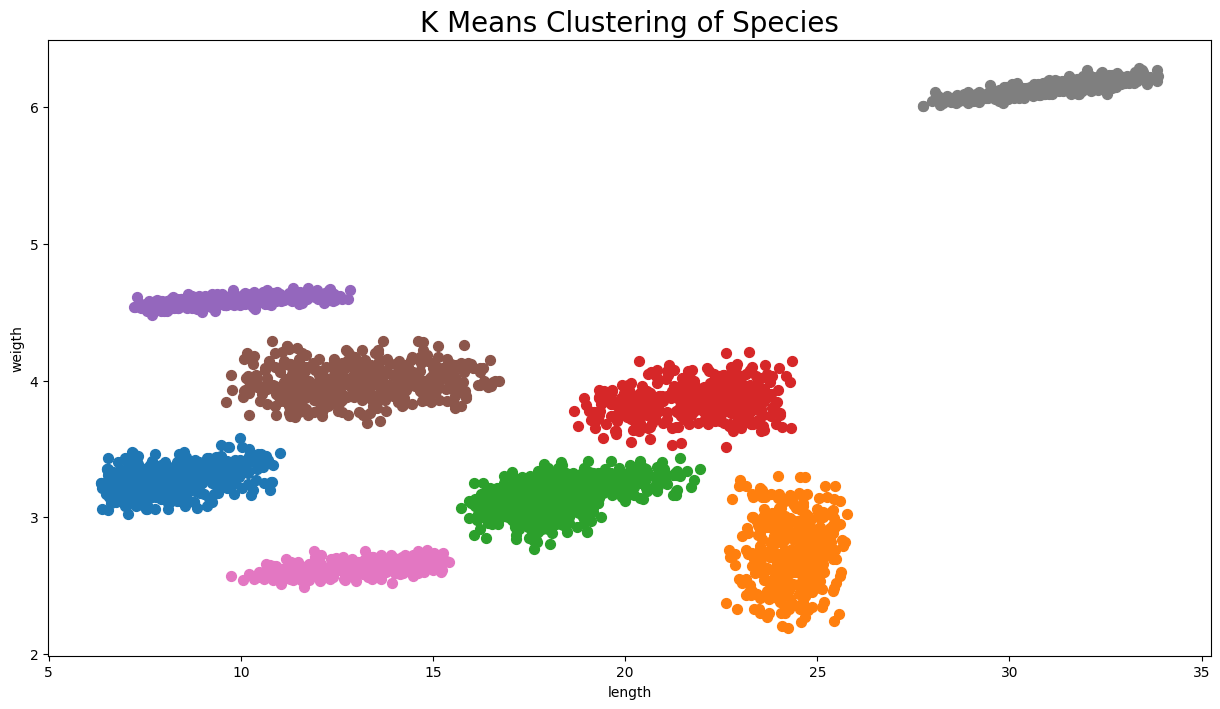

In [42]:
plt.figure(figsize= (15,8))

for i in range(len(np.unique(y_dbscan))):
    plt.scatter(X_transformed[y_dbscan == i, 0], X_transformed[y_dbscan == i, 1], s=50)

plt.title('K Means Clustering of Species', fontsize=20)
plt.xlabel('length')
plt.ylabel('weigth')

plt.show()

In [43]:
dbscan = DBSCAN(
    eps = 0.03,
    min_samples=10
)

y_dbscan = dbscan.fit_predict(X)

In [44]:
np.unique(y_dbscan)

array([-1,  0,  1])

In [45]:
dbscan = DBSCAN(
    eps = 0.03,
    min_samples=10
)

y_dbscan = dbscan.fit_predict(X_pca)

In [46]:
np.unique(y_dbscan)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7])